In [62]:
print("Allah is great")

Allah is great


In [63]:
import pandas as pd


In [64]:
df = pd.read_csv('insurance.csv')

In [65]:
#first five rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [66]:
#columns
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [67]:
df.shape

(1338, 7)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [69]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [70]:
#checking null values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [71]:
df.isnull().sum().sum()

np.int64(0)

In [72]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

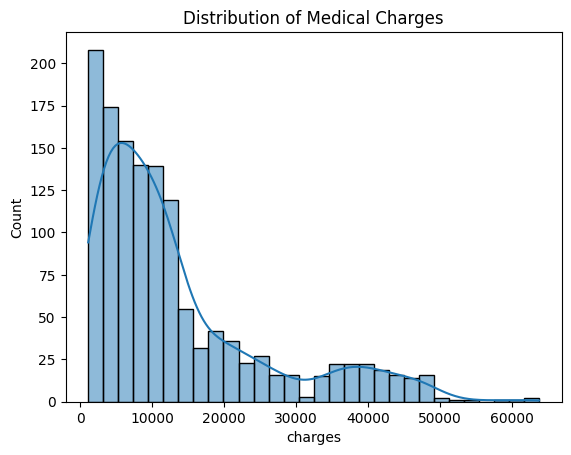

In [74]:
#distplot for chages vs people count
sns.histplot(df['charges'], kde = True)
plt.title("Distribution of Medical Charges")
plt.show()

### The distribution of medical charges is right-skewed, indicating that most individuals have relatively lower medical expenses, while a smaller number of individuals incur very high costs.

### The majority of charges lie in the lower range (below 15,000), whereas a few extreme values extend beyond 50,000, representing high-cost cases.

### This skewness suggests the presence of outliers and indicates that certain factors, such as smoking or health conditions, may significantly increase medical expenses.

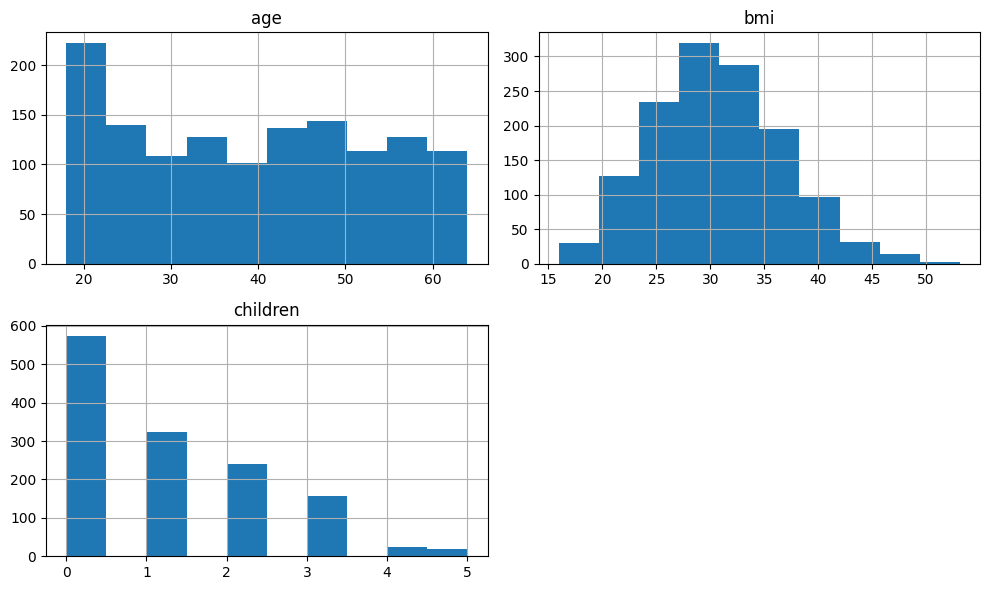

In [75]:
df[['age', 'bmi', 'children']].hist(figsize = (10,6))
plt.tight_layout()
plt.show()

### The distribution of age is fairly uniform across the dataset, indicating that individuals from different age groups are well represented.

### The BMI feature shows an approximately normal distribution, with most values concentrated between 25 and 35, suggesting that a majority of individuals fall within the normal to overweight range.

### The children feature is discrete in nature, with most individuals having 0 to 2 children, indicating limited variation in this feature.

### Overall, age and BMI provide meaningful variation for analysis, while the number of children may have a relatively smaller impact on medical charges.

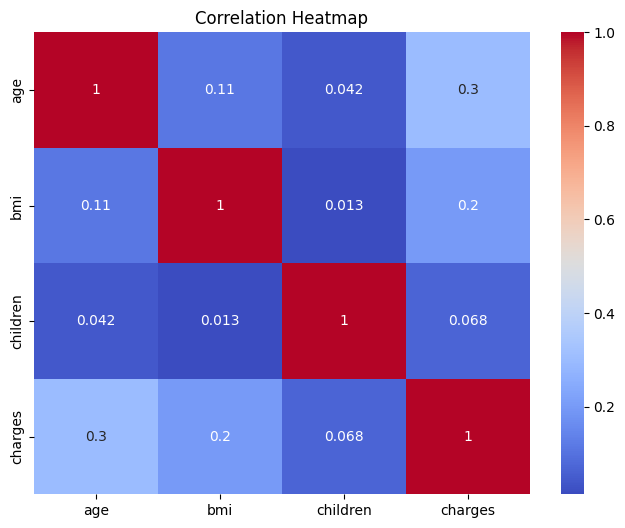

In [76]:
plt.figure(figsize = (8,6))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### The correlation heatmap shows the relationship between numerical features and medical charges. Among the features, age has the highest positive correlation with charges (around 0.30), followed by BMI (around 0.20), indicating that medical expenses tend to increase with age and body mass index.

### The number of children shows a very weak correlation with charges (around 0.06), suggesting it has minimal impact on medical costs.

### Overall, the correlations between numerical features and charges are relatively low, indicating that numerical variables alone do not strongly explain the variation in medical expenses. This suggests that other factors, particularly categorical variables such as smoking status, may have a more significant influence.

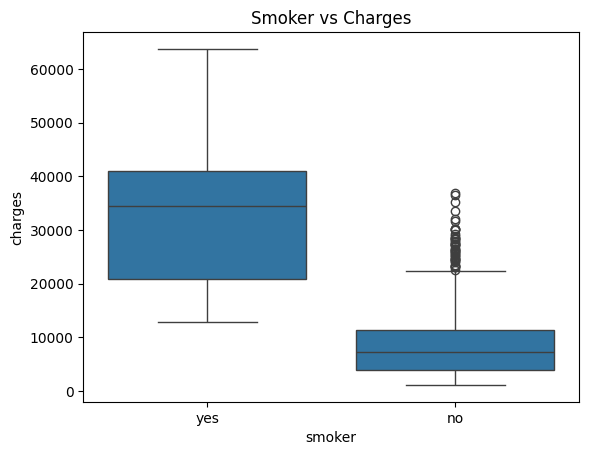

In [77]:
sns.boxplot(x = 'smoker', y = 'charges', data = df)
plt.title("Smoker vs Charges")
plt.show()

### The boxplot shows a significant difference in medical charges between smokers and non-smokers. Smokers have substantially higher median charges compared to non-smokers, with values often exceeding 30,000, while non-smokers mostly have charges below 15,000.

### There is a clear separation between the two groups, indicating that smoking status has a strong impact on medical expenses. Additionally, smokers show a wider spread in charges, suggesting higher variability in costs.

### This analysis highlights smoking as the most influential factor affecting medical insurance charges.

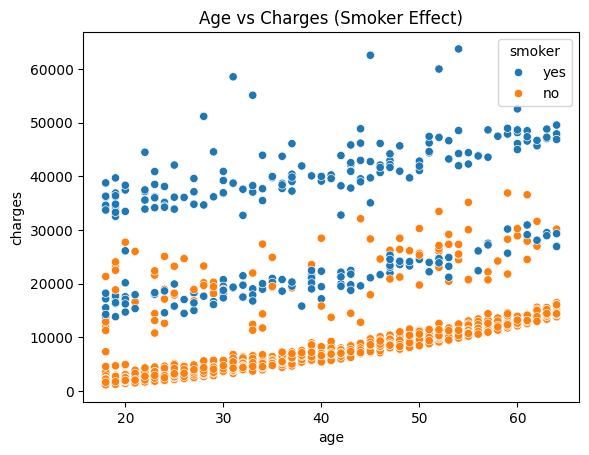

In [78]:
sns.scatterplot(x = 'age', y = 'charges', hue = 'smoker', data = df)
plt.title("Age vs Charges (Smoker Effect)")
plt.show()

### The scatter plot illustrates the relationship between age and medical charges, with smoking status as a distinguishing factor. It can be observed that medical charges generally increase with age, indicating a positive relationship between age and healthcare costs.

### A clear separation is visible between smokers and non-smokers. Smokers consistently incur significantly higher charges compared to non-smokers across all age groups.

### While age contributes to increasing medical expenses, smoking status has a much stronger impact, as even younger smokers tend to have higher charges than older non-smokers.

### This visualization confirms that both age and smoking influence medical charges, but smoking is the dominant factor.

In [79]:
df['sex'] = df['sex'].map( { 'male': 0, 'female':1})
df['smoker'] = df['smoker'].map({ 'yes': 1, 'no':0})

In [80]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [81]:
df = pd.get_dummies(df, columns = ['region'], drop_first = True)

In [82]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 66.8 KB


In [84]:
x = df.drop('charges', axis = 1)
y = df['charges']

In [85]:
x.shape , y.shape

((1338, 8), (1338,))

In [86]:
from sklearn.model_selection import train_test_split

In [87]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [88]:
x_train.shape, x_test.shape, y_train.shape , y_test.shape

((1070, 8), (268, 8), (1070,), (268,))

In [89]:
from sklearn.linear_model import LinearRegression


In [90]:
## Model Building
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [91]:
y_pred = model.predict(x_test)

In [92]:
from sklearn.metrics import mean_squared_error, r2_score

In [93]:
mse = mean_squared_error(y_test, y_pred)

In [94]:
r2 = r2_score(y_test, y_pred)

In [95]:
mse, r2

(33596915.85136146, 0.7835929767120723)

In [96]:
from sklearn.ensemble import RandomForestRegressor 

In [97]:
## Model Building for efficiency improvement
rf = RandomForestRegressor(random_state = 42)

In [98]:
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [99]:
y_pred_rf = rf.predict(x_test)

In [100]:
mse_rf = mean_squared_error(y_test, y_pred_rf)

In [101]:
r2_rf = r2_score(y_test, y_pred_rf)

In [102]:
mse_rf, r2_rf

(20709235.36684647, 0.8666060896739511)

In [103]:
features_importance = pd.Series(rf.feature_importances_, index = x.columns)

In [104]:
features_importance = features_importance.sort_values(ascending = False)

In [105]:
features_importance

smoker              0.608618
bmi                 0.217382
age                 0.134129
children            0.019440
sex                 0.005861
region_northwest    0.005369
region_southeast    0.005288
region_southwest    0.003913
dtype: float64